### CS4423 - Networks
Anton Baykalov  
School of Mathematical and Statistical Sciences  
University of Galway  

[![Open in Binder](images/badge_logo.png)](https://mybinder.org/v2/gh/anton-baykalov/networks/HEAD)

https://mybinder.org/v2/gh/anton-baykalov/networks/HEAD

#### 5. Small Worlds

# Week 10, lecture 2: 


# Watts-Strogatz model and real Small-world networks

**Definition (Circle Graph).** For $1 < d < n/2$, an $(n, d)$-**circle graph**
is obtained from a cycle on $n$ vertices by additionally linking each node
to all nodes that are not more than $d$ steps away on the cycle.


In [1]:
import networkx as nx
opts = { "with_labels": True, "node_color": 'y' }

In [5]:
def circle_graph(n, d):
    G = nx.cycle_graph(n)
    for v in G:
        for o in range(2, d+1):
            G.add_edge(v, (v+o) % n)
    return G

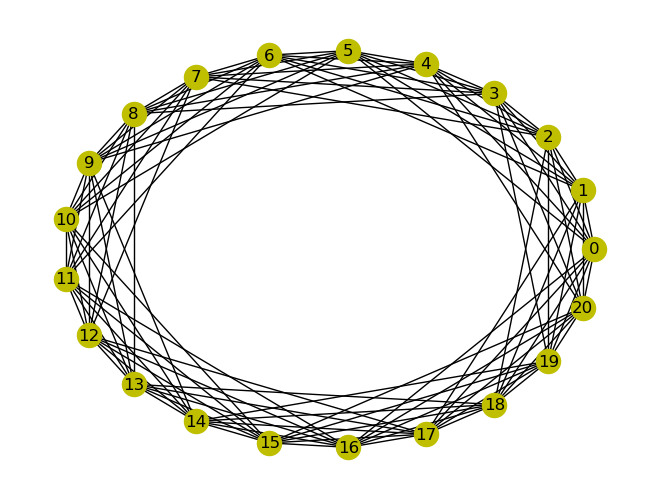

In [6]:
G = circle_graph(21, 5)
nx.draw_circular(G, **opts)

## The Watts-Strogatz Model

The following modification of the circle graph was suggested by Duncan J. Watts and Steven Strogatz ([1998](https://en.wikipedia.org/wiki/Watts%E2%80%93Strogatz_model)). The idea is to introduce a probabilistic element to the graph, which results in "shortcuts" between the nodes and in a shortening of the characteristic path length.

**Definition (The WS Model).**
Let $1 < d < n/2$ and $0\leq p \leq 1$.  An $(n, d, p)$-WS graph $G = (X, E)$ is constructed from
an $(n, d)$-circle graph $G_0 = (X, E_0)$ by rewiring each of the edges in $E_0$ with probability $p$,
as follows:

1. visit the nodes $X = \{0, \dots, n{-}1\}$ in turn ('clockwise').

2. for each node $i \in X$ consider the $d$ edges connecting $i$ to $j$
in a clockwise sense ($j = i+1, \dots, i+d$).

3. With probability $p$, in the edge $(i, j)$ replace
$j$ by node $k \in X$ chosen uniformly at random, subject to
  * $k \neq i$, and
  * $(i, k)$ must not be an edge of $G$ already.

In [11]:
import random as rd
def ws_graph(n, d, p):
    G = circle_graph(n, d)
    for v in G:
        for o in range(1, d+1):
            if rd.random() < p:
                w = rd.randint(0,n-1)
                if w != v and not G.has_edge(v, w):
                    G.remove_edge(v, (v+o) % n)
                    G.add_edge(v, w)
    return G

0.3405238095238095
2.59265306122449
(50, 150)


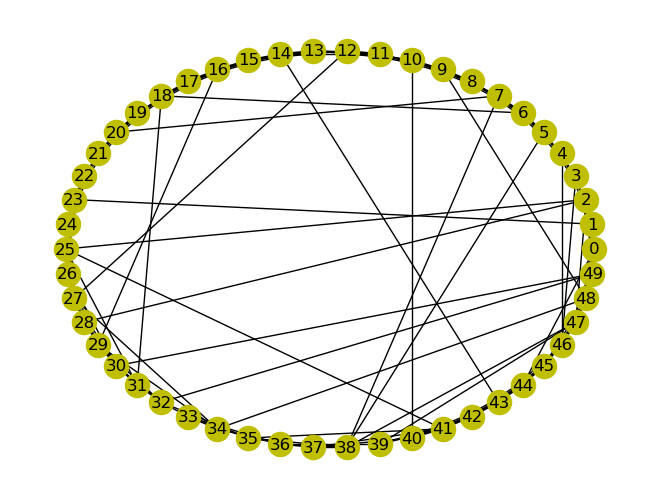

In [32]:
n, d = 50, 3
G = ws_graph(n, d, 0.2)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))
print((G.order(), G.size()))

## Famous small-world networks

# Zachary's Karate Club

The **Zachary's Karate Club** is a classic social network dataset that represents friendships between members of a university karate club studied by Wayne W. Zachary in the 1970s. The network contains 34 nodes (members) and 78 edges (social ties), capturing how individuals in a small community interact.  This dataset became particularly notable because it reflects a real **conflict within the club** that eventually **split it into two factions**, making it a valuable example for studying community structure.

Structurally, the network exhibits key features of real-world social systems, such as high clustering and relatively short path lengths, indicating a “small-world” nature. However, unlike simple models, it also shows variation in node connectivity, with certain individuals acting as central hubs. Because of its manageable size and rich structure, the karate network is widely used in network science for testing algorithms related to community detection, centrality measures, and graph visualization, as well as for comparing real-world data to theoretical models like the Watts–Strogatz network.

In [2]:
G_karate = nx.karate_club_graph()
G_karate.order(), G_karate.size()

(34, 78)

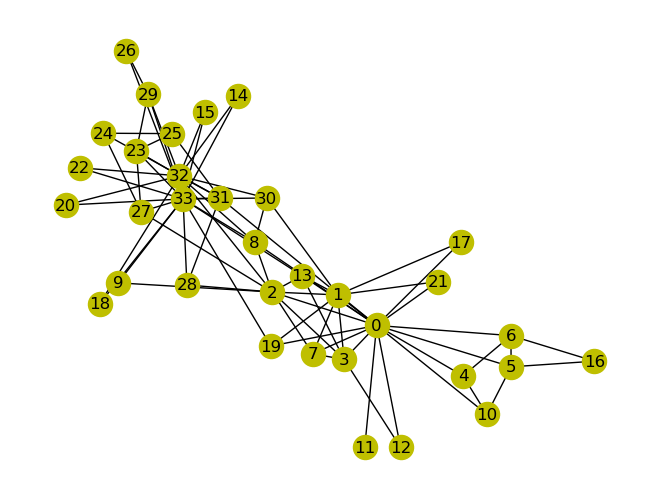

In [8]:
nx.draw(G_karate, **opts)

Extructing parameters: order and average degree

In [11]:
n = G_karate.number_of_nodes()
k = (sum(dict(G_karate.degree()).values()) / n) #average degree 
n,k

(34, 4.588235294117647)

Create WS graph: recall that `nx.watts_strogatz_graph` tales parameters $n,k,p$ where $k$ is the degree of the nodes in initial circle graph, so it corresponds to `ws_graph(n,k/2,p)` above. In particular, $k$ must be even.

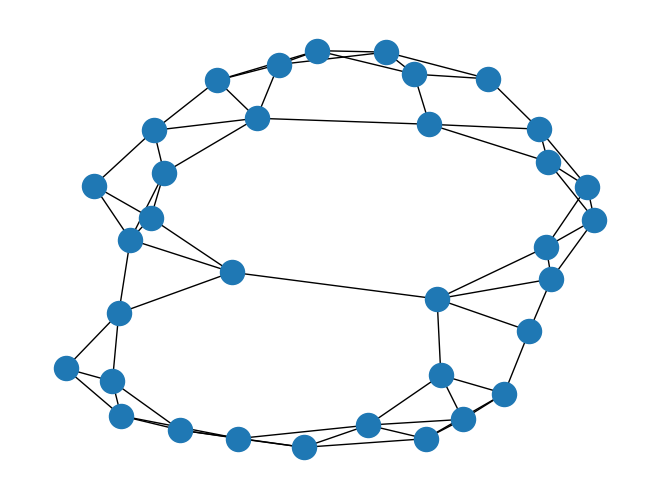

In [13]:
G_ws = nx.watts_strogatz_graph(n=34, k=4, p=0.1)
nx.draw(G_ws)

## Comparing:

1. Clustering coefficient

In [44]:
G_ws = nx.watts_strogatz_graph(n=34, k=4, p=0.1)
print(nx.average_clustering(G_karate))
print(nx.average_clustering(G_ws))

0.5706384782076823
0.3362745098039216


2. Charcteristic path length $L$:

In [54]:
G_ws = nx.watts_strogatz_graph(n=34, k=4, p=0.1)
print(nx.average_shortest_path_length(G_karate))
print(nx.average_shortest_path_length(G_ws))

2.408199643493761
3.4402852049910875


Degree distribution:

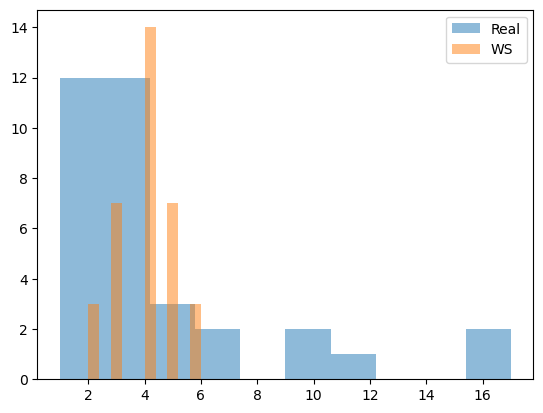

In [3]:
import matplotlib.pyplot as plt
G_ws = nx.watts_strogatz_graph(n=34, k=4, p=0.5)
plt.hist([d for n, d in G_karate.degree()], alpha=0.5, label="Real")
plt.hist([d for n, d in G_ws.degree()], alpha=0.5, label="WS")
plt.legend()
plt.show()

In [73]:
print(' ', nx.average_clustering(G_karate), nx.average_shortest_path_length(G_karate))
for p in [0.01, 0.05, 0.1, 0.3, 0.5]:
    G_ws = nx.watts_strogatz_graph(34, 4, p)
    print(p, nx.average_clustering(G_ws), nx.average_shortest_path_length(G_ws))

  0.5706384782076823 2.408199643493761
0.01 0.4588235294117647 3.798573975044563
0.05 0.4892156862745098 4.308377896613191
0.1 0.39999999999999997 3.121212121212121
0.3 0.21470588235294116 2.7379679144385025
0.5 0.08634453781512605 2.6345811051693406


# Dolphins network

The **Dolphins social network** represents associations between a group of 62 bottlenose dolphins living off the coast of New Zealand. Compiled by Mark Newman, the network captures frequent social interactions observed over time, where nodes correspond to individual dolphins and edges indicate preferred companionship. As an undirected and unweighted graph, it provides a clear snapshot of how social relationships form within an animal community.

Structurally, the network exhibits key characteristics of real-world social systems, including relatively high clustering and short path lengths, suggesting a small-world organization. It also contains variation in node connectivity, with certain dolphins playing more central roles in maintaining group cohesion.

In [4]:
import yaml
import urllib.request

url = "https://anton-baykalov.github.io/networks_data/Dolphins.txt"
urllib.request.urlretrieve(url, "Dolphins.txt")

G_dol = nx.read_gml("Dolphins.txt")

In [5]:
print(G_dol.nodes)
print("Order: ",G_dol.order())
print("Size: ", G_dol.size())

['Beak', 'Beescratch', 'Bumper', 'CCL', 'Cross', 'DN16', 'DN21', 'DN63', 'Double', 'Feather', 'Fish', 'Five', 'Fork', 'Gallatin', 'Grin', 'Haecksel', 'Hook', 'Jet', 'Jonah', 'Knit', 'Kringel', 'MN105', 'MN23', 'MN60', 'MN83', 'Mus', 'Notch', 'Number1', 'Oscar', 'Patchback', 'PL', 'Quasi', 'Ripplefluke', 'Scabs', 'Shmuddel', 'SMN5', 'SN100', 'SN4', 'SN63', 'SN89', 'SN9', 'SN90', 'SN96', 'Stripes', 'Thumper', 'Topless', 'TR120', 'TR77', 'TR82', 'TR88', 'TR99', 'Trigger', 'TSN103', 'TSN83', 'Upbang', 'Vau', 'Wave', 'Web', 'Whitetip', 'Zap', 'Zig', 'Zipfel']
Order:  62
Size:  159


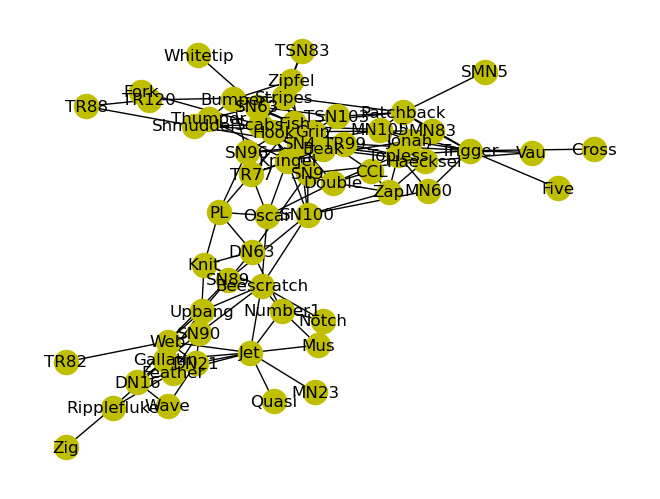

In [80]:
nx.draw(G_dol, **opts)

In [81]:
n = G_dol.number_of_nodes()
k = (sum(dict(G_dol.degree()).values()) / n) #average degree 
n,k

(62, 5.129032258064516)

In [92]:
G_ws = nx.watts_strogatz_graph(n=62, k=6, p=0.1)
print(nx.average_clustering(G_dol))
print(nx.average_clustering(G_ws))

0.2589582460550202
0.48701996927803376


2. Charcteristic path length $L$:

In [111]:
G_ws = nx.watts_strogatz_graph(n=62, k=6, p=0.1)
print(nx.average_shortest_path_length(G_dol))
print(nx.average_shortest_path_length(G_ws))

3.3569539925965097
3.4114225277630883


Degree distribution:

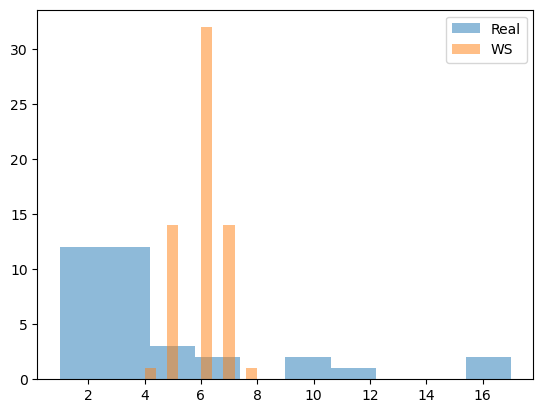

In [126]:
import matplotlib.pyplot as plt
G_ws = nx.watts_strogatz_graph(n=62, k=6, p=0.1)
plt.hist([d for n, d in G_karate.degree()], alpha=0.5, label="Real")
plt.hist([d for n, d in G_ws.degree()], alpha=0.5, label="WS")
plt.legend()
plt.show()

In [135]:
print(' ', nx.average_clustering(G_dol), nx.average_shortest_path_length(G_dol))
for p in [0.01, 0.05, 0.1, 0.3, 0.5]:
    G_ws = nx.watts_strogatz_graph(34, 6, p)
    print(p, nx.average_clustering(G_ws), nx.average_shortest_path_length(G_ws))

  0.2589582460550202 3.3569539925965097
0.01 0.5869747899159663 3.212121212121212
0.05 0.5043417366946779 2.700534759358289
0.1 0.5011904761904762 2.522281639928699
0.3 0.3399859943977591 2.2459893048128343
0.5 0.20723198370257193 2.121212121212121


The dolphins social network shows characteristics of a small-world network, including high clustering and short average path lengths, which are also reproduced by the Watts–Strogatz model. However, the real network differs in its degree distribution, exhibiting greater variability and the presence of more highly connected nodes. In contrast, the Watts–Strogatz model generates a more regular structure with less variation in node degree, meaning it captures the small-world effect but not the full complexity of real-world social networks.

# Marvel heroes 

The Marvel co-appearance network is an undirected graph where nodes are characters and edges indicate co-appearances in comics, weighted by frequency. It is not fully connected, with a large central component containing most popular heroes and villains. The network shows high clustering and short path lengths, similar to a Watts-Strogatz small-world network, but its degree distribution is highly heterogeneous.

In [1]:
from datasets import load_dataset
import pandas as pd
import networkx as nx

# Load the adjacency list config
dataset = load_dataset("ShimizuYuki/Marvel_network", "adjacency_list")

# Convert to DataFrame
df = pd.DataFrame(dataset["train"])  # usually the only split

# Inspect
print(df.head())

# Build an undirected NetworkX graph with 'counts' as weight
G = nx.Graph()
for _, row in df.iterrows():
    hero1 = row["hero1"]
    hero2 = row["hero2"]
    weight = row["counts"]
    G.add_edge(hero1, hero2, weight=weight)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

README.md: 0.00B [00:00, ?B/s]

adjacency_list.csv:   0%|          | 0.00/5.12M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/142289 [00:00<?, ? examples/s]

                  hero1                 hero2  counts
0  24-HOUR MAN/EMMANUEL       FROST, CARMILLA       1
1  24-HOUR MAN/EMMANUEL                G'RATH       1
2  24-HOUR MAN/EMMANUEL  KILLRAVEN/JONATHAN R       1
3  24-HOUR MAN/EMMANUEL             OLD SKULL       1
4  3-D MAN/CHARLES CHAN  AJAK/TECUMOTZIN [ETE       1
Nodes: 6267
Edges: 142289


In [2]:
import random

# Number of random nodes to display
num_nodes = 5

# Sample random nodes
random_nodes = random.sample(list(G.nodes), num_nodes)
print("Random nodes:", random_nodes)


Random nodes: ['BUKOWSKI, BUCK', 'CHAKRA II', 'NETTLES', 'MAD VIKING/KNUT CAIN', 'BARBAROSSA, MARIO']


In [3]:
# Number of random edges to display
num_edges = 5

# Sample random edges
random_edges = random.sample(list(G.edges(data=True)), num_edges)
for u, v, attr in random_edges:
    print(f"{u} -- {v}, weight={attr['weight']}")

HEIMDALL [ASGARDIAN] -- ARKO, weight=3
MIRAGE II/DANIELLE M -- HELA [ASGARDIAN], weight=12
SENTINELS -- DE LA FONTAINE, CONT, weight=1
PYRO/ALLERDYCE JOHNN -- STRUCKER, ANDREAS, weight=2
CALEDONIA/ALISANDE S -- TECHNARX, weight=1


In [4]:
# Check node existence
#if "STACY, GWEN" in G:
if "THANOS" in G:
    print("In the network!")
else:
    print("Not in the network.")

In the network!


In [5]:
hero = "STACY, GWEN"

In [6]:
degree = G.degree(hero)  # unweighted
weighted_degree = G.degree(hero, weight="weight")  # sum of edge weights
degree, weighted_degree

(78, 573)

In [7]:

print("Order: ",G.order())
print("Size: ", G.size())

Order:  6267
Size:  142289


In [8]:
n = G.number_of_nodes()
k = (sum(dict(G.degree()).values()) / n) #average degree 
n,k

(6267, 45.408967608105954)

In [9]:
G_ws = nx.watts_strogatz_graph(n=n, k=46, p=0.1)
print(nx.average_clustering(G))
print(nx.average_clustering(G_ws))

0.7600947241817142
0.5393939633355508


2. Charcteristic path length $L$:

In [10]:
# Each component is a set of nodes
components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")

Number of connected components: 19


In [11]:
# Print the size of each component
for i, comp in enumerate(components, 1):
    print(f"Component {i}: {len(comp)} nodes")

Component 1: 6198 nodes
Component 2: 7 nodes
Component 3: 5 nodes
Component 4: 9 nodes
Component 5: 7 nodes
Component 6: 3 nodes
Component 7: 2 nodes
Component 8: 2 nodes
Component 9: 3 nodes
Component 10: 3 nodes
Component 11: 5 nodes
Component 12: 2 nodes
Component 13: 3 nodes
Component 14: 3 nodes
Component 15: 2 nodes
Component 16: 4 nodes
Component 17: 2 nodes
Component 18: 4 nodes
Component 19: 3 nodes


In [12]:
G1 =  G.subgraph(components[0]).copy()

In [13]:
G1.order()

6198

In [14]:
G_ws = nx.watts_strogatz_graph(n=n, k=46, p=0.1)
print(nx.average_shortest_path_length(G1))
print(nx.average_shortest_path_length(G_ws))

2.745180075735363
3.08080002603579


Degree distribution:

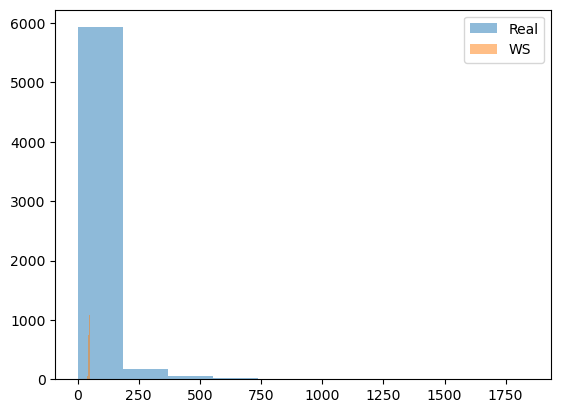

In [15]:
import matplotlib.pyplot as plt
G_ws = nx.watts_strogatz_graph(n=6198, k=46, p=0.1)
plt.hist([d for n, d in G1.degree()], alpha=0.5, label="Real")
plt.hist([d for n, d in G_ws.degree()], alpha=0.5, label="WS")
plt.legend()
plt.show()

In [193]:
G_ws.order()

6198

In [ ]:
print(' ', nx.average_clustering(G1), nx.average_shortest_path_length(G1))
for p in [0.01, 0.05, 0.1, 0.3, 0.5]:
    G_ws = nx.watts_strogatz_graph(n, 46, p)
    print(p, nx.average_clustering(G_ws), nx.average_shortest_path_length(G_ws))

  0.7591065195023191 2.745180075735363
0.01 0.7108607617409124 4.27284921941779
0.05 0.6289073456516693 3.353760834685417
0.1 0.5373156674546963 3.079580744333281
0.3 0.2573216733480106 2.824933811695132


## [Marvel Universe looks almost like a real social network](https://arxiv.org/abs/cond-mat/0202174)


Original studies of the Marvel Universe network note that it “looks almost like a real social network”, with patterns akin to collaboration networks.

1. The Marvel co‑appearance network shares some key small‑world properties with the Watts–Strogatz model: it typically has **short average path lengths** between nodes and **high clustering**, meaning characters connected to a character are often connected to each other too.

However, the structure of the Marvel network also differs from a pure WS:

1. The Marvel network has a heterogeneous (broad) degree distribution with hubs (e.g., highly connected characters like Spider‑Man), whereas the basic WS model starts from a regular lattice with a much narrower degree distribution.

Real co‑appearance networks (like movie actors, scientific co‑authorship networks, and the Marvel universe) often show [scale‑free–like](https://en.wikipedia.org/wiki/Scale-free_network) behavior or fat tails in degree, which WS does not generate naturally.

Thus, while the WS model helps illustrate why real networks can have “small world” behavior (short distances and clustering), the Marvel network’s degree heterogeneity and real collaboration patterns often resemble other complex network models more closely, such as scale‑free or hierarchical models.
